In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("clean_data.csv")

df.head()

,environment,test,sensor,sample_index,timestamp,addr,rssi,lqi,source_file
0,bridge,1,sensor_1,1,"2026-03-05 16:36:37,951",fe80::e41d:23d2:4964:c6f9,-88,20,Bridge 1.log
1,bridge,1,sensor_1,2,"2026-03-05 16:36:37,956",fe80::e41d:23d2:4964:c6f9,-87,24,Bridge 1.log
2,bridge,1,sensor_1,3,"2026-03-05 16:36:37,976",fe80::e41d:23d2:4964:c6f9,-88,20,Bridge 1.log
3,bridge,1,sensor_1,4,"2026-03-05 16:36:37,990",fe80::e41d:23d2:4964:c6f9,-88,20,Bridge 1.log
4,bridge,1,sensor_1,5,"2026-03-05 16:36:37,999",fe80::e41d:23d2:4964:c6f9,-88,20,Bridge 1.log


In [3]:
df['run_id'] = (
    df['environment'] + "_" +
    df['test'].astype(str) + "_" +
    df['sensor']
)

In [4]:
def differentiate(x):
    return np.diff(x)

In [5]:
def normalize(x):

    xmin = x.min()
    xmax = x.max()

    if xmax == xmin:
        return np.zeros_like(x)

    return (x-xmin)/(xmax-xmin)

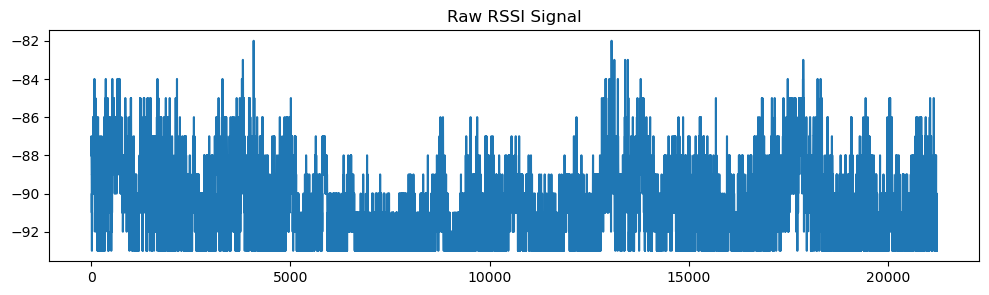

In [6]:
sample = df[df['run_id']==df['run_id'].iloc[0]]['rssi'].values

plt.figure(figsize=(12,3))
plt.plot(sample)
plt.title("Raw RSSI Signal")
plt.show()

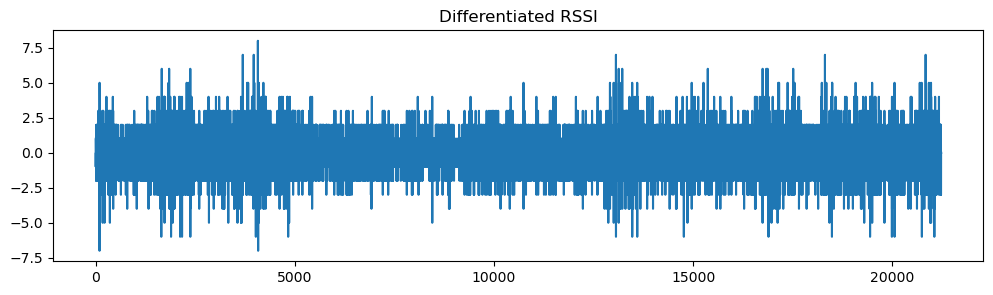

In [7]:
diff = differentiate(sample)

plt.figure(figsize=(12,3))
plt.plot(diff)
plt.title("Differentiated RSSI")
plt.show()

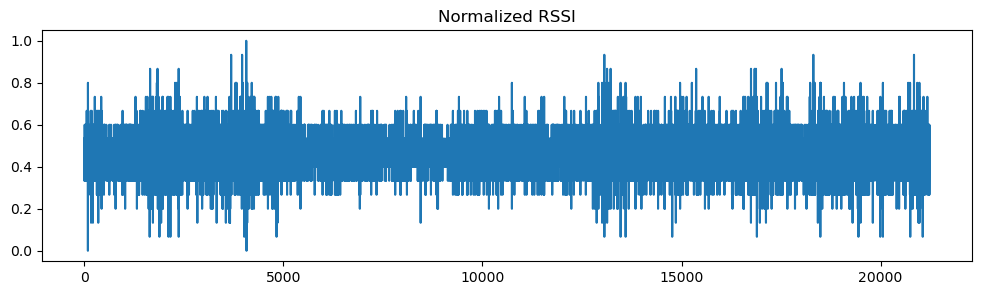

In [8]:
norm = normalize(diff)

plt.figure(figsize=(12,3))
plt.plot(norm)
plt.title("Normalized RSSI")
plt.show()